# Trabajo Práctico - Aprendizaje Automático

## SetUp




In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import shapiro

from six import StringIO  #pip3 install six

from IPython.display import Image, display
import pydotplus

import sklearn
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


In [ ]:
# Seteamos la semilla para que los resultados sean reproducibles
SEED = 2026
np.random.seed(SEED)

# Definimos el K-Fold estratificado para usar en la validación cruzada de los modelos
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Definición de Funciones

In [ ]:
# Función para separar el dataset en train y test, manteniendo la proporción de clases
def train_test_split(df):
    buen_pronostico = df[df['target'] == 1]
    p = buen_pronostico.shape[0]/df.shape[0]

    mal_pronostico = df[df['target'] == 0]
    buenos = len(buen_pronostico)/len(df)
    filasBuenas = int(len(df)*buenos*p)
    filasMalas = int(len(df)*p-filasBuenas)
    # buscar como selecciona .sample()
    test = pd.DataFrame(columns=buen_pronostico.columns).astype(buen_pronostico.dtypes)
    test = pd.concat([test, buen_pronostico.sample(n=filasBuenas, random_state=SEED)], ignore_index=False)
    test = pd.concat([test, mal_pronostico.sample(n=filasMalas, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)    
    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

In [ ]:
# Función para entrenar un árbol de decisión con una semilla fija
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

def dibujar_arbol(clf, c_name=['0','1'], f_name=df.drop(columns=['target']).columns):
    # modo de uso: dibujar_arbol(arbol, nombres_de_clases, nombres_de_features)
    if(c_name is None or f_name is None):
        return "Debe especificar los nombres de las clases y de las features"
    
    dot_data = StringIO()
    sklearn.tree.export_graphviz(clf, out_file = dot_data,
                    filled = True,
                    class_names = c_name,
                    feature_names = f_name,
                    special_characters = True)

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))

## Separación de Datos de Desarrollo y Control

In [7]:
df_completo = pd.read_csv('data.csv')

In [ ]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control, y_control = train_test_split(df_completo)

df_control = pd.concat([X_control, y_control], axis=1)
df = pd.concat([X_train, y_train], axis=1)

Decidimos dividir los datos en Desarrollo y Control. Si bien más adelante contaremos con un conjunto de datos de control, esta primera instancia de validación nos permite ajustar el modelo y asegurar su capacidad de generalización antes datos totalmente nuevos. Una vez validada esta etapa, integraremos nuestros datos de control interno al conjunto de entrenamiento general.     

Para asegurar una representación fiel de los datos, utilizamos siempre particiones estratificadas (stratify), lo que nos permite controlar el desbalance de clases.

## Ejercicio 2

### Ejercicio 2.1

In [ ]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Score sobre el dataset de entrenamiento:  0.8326848249027238
Score sobre el dataset de prueba:  0.6764705882352942


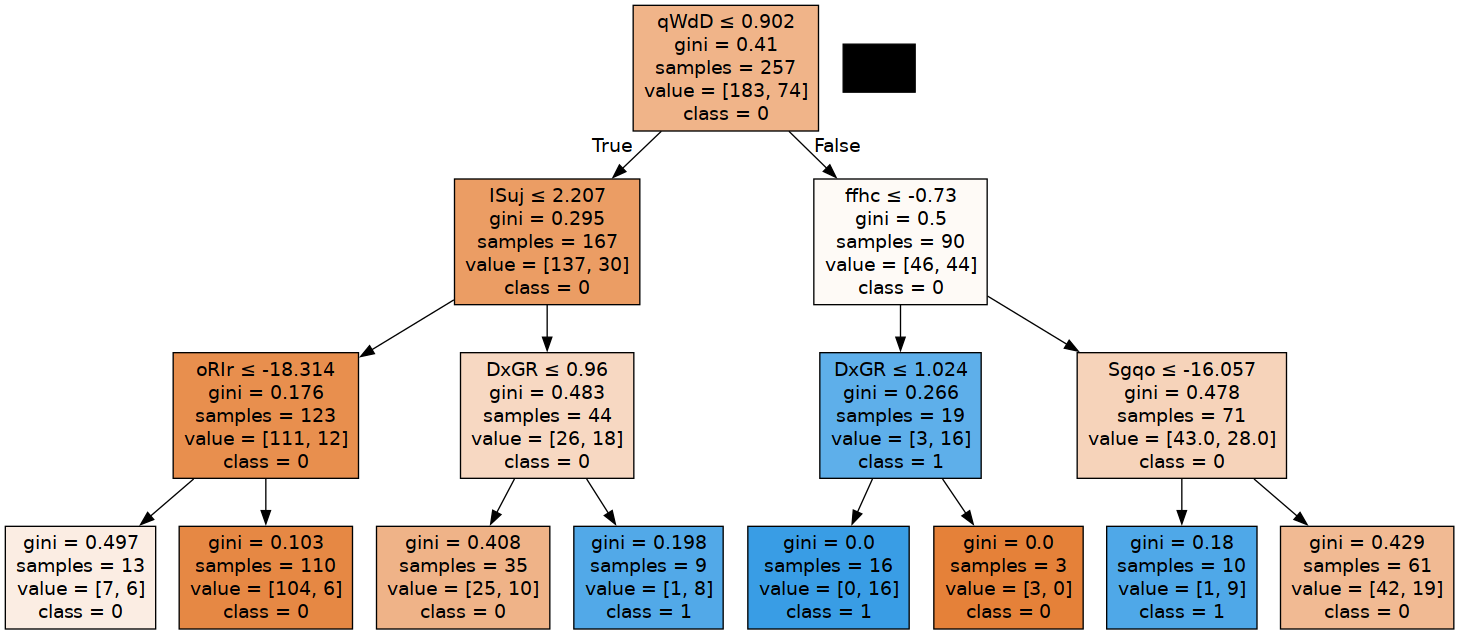

In [45]:
dibujar_arbol(tree_1)

### Ejercicio 2.2

In [ ]:
X_train, y_train = df.drop(columns=['target']), df['target']
resultados_folds = []

y_global_true = np.empty(len(y_train))
y_global_pred = np.empty(len(y_train))
y_global_proba = np.empty(len(y_train)) # El nombre proba es por aucroc devuelve la probabilidad de pertenecer a la clase.

for fold_idx, (train_index, val_index) in enumerate(stratifiedKFold.split(X_train, y_train)):

    kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
    kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

    tree = train_tree(kf_X_train, kf_y_train, tree_params={'max_depth': 3})

    y_pred_train = tree.predict(kf_X_train)
    y_pred_proba_train = tree.predict_proba(kf_X_train)[:, 1] # Probabilidad de pertenecer a la clase positiva

    y_pred_test = tree.predict(kf_X_test)
    y_pred_proba_test = tree.predict_proba(kf_X_test)[:, 1] # Probabilidad de pertenecer a la clase positiva

    y_global_true[val_index] = kf_y_test
    y_global_pred[val_index] = y_pred_test
    y_global_proba[val_index] = y_pred_proba_test


    resultados_folds.append({
        'Permutación': str(fold_idx),
        'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
        'Accuracy (validation)': accuracy_score(kf_y_test, y_pred_test),
        'AUC-PRC (train)': average_precision_score(kf_y_train, y_pred_proba_train),
        'AUC-PRC (validation)': average_precision_score(kf_y_test, y_pred_proba_test),
        'AUC-ROC (train)': roc_auc_score(kf_y_train, y_pred_proba_train),
        'AUC-ROC (validation)': roc_auc_score(kf_y_test, y_pred_proba_test)
    })

df_tabla = pd.DataFrame(resultados_folds)

promedios = df_tabla.drop(columns=['Permutación']).mean()
df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)


df_tabla.loc[len(df_tabla)] = [
    'Global',
    '(NO)',
    accuracy_score(y_global_true, y_global_pred),
    '(NO)',
    average_precision_score(y_global_true, y_global_proba),
    '(NO)',
    roc_auc_score(y_global_true, y_global_proba)
]

In [50]:
df_tabla

,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,0.868293,0.711538,0.769072,0.463023,0.887799,0.573874
1,1,0.858537,0.673077,0.782217,0.369452,0.889018,0.617117
2,2,0.830097,0.803922,0.679194,0.465236,0.884989,0.629344
3,3,0.854369,0.705882,0.750141,0.447925,0.865272,0.660185
4,4,0.849515,0.666667,0.708362,0.418122,0.906953,0.688889
5,Promedios,0.852162,0.712217,0.737797,0.432752,0.886806,0.633882
6,Global,(NO),0.712062,(NO),0.409792,(NO),0.625425


### Ejer 2.3

In [51]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []
    
    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)
        
        cv_results = cross_validate(
            current_tree, 
            X_train, 
            y_train, 
            cv=stratifiedKFold, 
            scoring=metric, 
            return_train_score=True 
        )
        
        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value
                
        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()
        
        res.append(fila)

    return pd.DataFrame(res)

In [ ]:
X_train, y_train = df.drop(columns=['target']), df['target']
res = grid_search_tree(X_train, y_train)

res

## Ejercicio 3

In [ ]:
# Función para generar una tabla de resultados a partir de un objeto RandomizedSearchCV entrenado
def generar_tabla_resultados(busqueda_entrenada):
    df_resultados = pd.DataFrame(busqueda_entrenada.cv_results_)
    
    columnas_params = [col for col in df_resultados.columns if col.startswith('param_')]
    columnas_metricas = [
        'rank_test_score',
        'mean_test_score',
        'std_test_score'
    ]

    columnas_totales = columnas_metricas + columnas_params
    tabla_limpia = df_resultados[columnas_totales].sort_values(by='rank_test_score')
    
    mapeo_nombres = {col: col.replace('param_', '') for col in columnas_params}
    tabla_limpia = tabla_limpia.rename(columns=mapeo_nombres)
    
    return tabla_limpia

### Ejercicio 3.1

#### Árboles de Decisión

In [128]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 5, 6, 7, None],
        'criterion': ['gini', 'entropy'],
        'max_features' : [None, 'sqrt', 'log2'],
        'min_samples_split' : [2, 3, 4, 5],
    }, # restringe el espacio de búsqueda a estos valores
    n_iter=10, # combinaciones aleatorias a probar
    scoring='roc_auc', # métrica a optimizar
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto permite usar todos los cores de CPU
)

random_search_tree.fit(X_train, y_train)

generar_tabla_resultados(random_search_tree)

,rank_test_score,mean_test_score,std_test_score,min_samples_split,max_features,max_depth,criterion
8,1,0.642855,0.026969,4,log2,3,gini
3,2,0.631872,0.088570,3,None,3,entropy
5,3,0.615945,0.067344,2,log2,None,entropy
9,4,0.615384,0.070609,4,None,5,entropy
1,5,0.588892,0.061876,4,sqrt,7,gini
6,6,0.580718,0.100473,4,sqrt,6,entropy
4,7,0.573726,0.069845,4,log2,7,gini
2,8,0.565449,0.084953,2,sqrt,5,gini
7,9,0.564359,0.067399,3,sqrt,7,gini
0,10,0.548128,0.049041,3,sqrt,None,gini


#### KNN

In [161]:
rsk = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={
        'n_neighbors': range(1,20),
        'weights': ["uniform","distance"],
        'metric':["cityblock","cosine","euclidean"]
    }, 
    n_iter=10, 
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    
)

rsk.fit(X_train, y_train)

generar_tabla_resultados(rsk)

,rank_test_score,mean_test_score,std_test_score,weights,n_neighbors,metric
9,1,0.832651,0.024303,distance,4,cosine
6,2,0.814244,0.019154,uniform,5,cosine
7,3,0.803655,0.037518,uniform,10,cityblock
5,4,0.802813,0.013292,uniform,19,cosine
2,5,0.792802,0.022356,uniform,12,euclidean
1,6,0.791084,0.024979,uniform,6,cityblock
8,7,0.774666,0.023855,uniform,7,euclidean
0,8,0.727904,0.045285,distance,3,euclidean
4,9,0.713931,0.041534,uniform,3,euclidean
3,10,0.702231,0.055826,distance,1,cosine


#### SVM

### Ejercicio 3.2

#### LDA

In [ ]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = LinearDiscriminantAnalysis()

resultados_nb = cross_validate(
    nb_model,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de LDA: {aucroc_promedio_nb:.4f}")

#### Naive Bayes

In [ ]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = GaussianNB()

resultados_nb = cross_validate(
    nb_model, 
    X_train,
    y_train, 
    cv=stratifiedKFold, 
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

AUCROC promedio de Naïve Bayes (Default): 0.7283


## Extras: Análisis de los Datos

### Análisis de Correlación

#### Correlación sin condicionar por Clase

In [ ]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes) # Qué gen tiene una correlación marcada.

#### Correlación dada la Clase

In [ ]:
X_0 = df[df['target'] == 0].drop(columns=['target'])
X_1 = df[df['target'] == 1].drop(columns=['target'])

corr_0 = X_0.corr(method='spearman')
corr_1 = X_1.corr(method='spearman')

mask = np.triu(np.ones_like(corr_0, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_0, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[0].set_title('Matriz de Correlación - Clase 0')
axes[0].set_xlabel('Genes')
axes[0].set_ylabel('Genes')

sns.heatmap(
    corr_1, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[1].set_title('Matriz de Correlación - Clase 1')
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
print("Genes con correlación fuerte en Clase 0:")
correlaciones_apiladas_0 = corr_0.mask(mask).stack()
correlaciones_fuertes_0 = correlaciones_apiladas_0[abs(correlaciones_apiladas_0) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_0)

print("\nGenes con correlación fuerte en Clase 1:")
correlaciones_apiladas_1 = corr_1.mask(mask).stack()
correlaciones_fuertes_1 = correlaciones_apiladas_1[abs(correlaciones_apiladas_1) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_1)

### Análisis de Normalidad en los Atributos dada la Clase

In [ ]:
resultados_condicionales = []

for clase in ['0', '1']:
    df_clase = df[df['target'] == clase].drop(columns=['target'])
    
    for gen in df_clase.columns:
        data = df_clase[gen].dropna()
        
        _, p_shapiro = shapiro(data)
        es_normal_shapiro = p_shapiro > 0.05
             
        resultados_condicionales.append({
            'Clase': clase,
            'Gen': gen,
            'p_valor_Shapiro': p_shapiro,
            'Normal_Shapiro': es_normal_shapiro,
        })

df_tests_condicional = pd.DataFrame(resultados_condicionales)

display(df_tests_condicional.sort_values(by=['Clase', 'p_valor_Shapiro'], ascending=[True, True]).head(15))

#### Histogramas de Atributos dada la Clase

In [ ]:
target = 'target'
features = [col for col in df.columns if col != target]
features = features[:12]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue=target,
        kde=True,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {feature} por clase")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis de Normalidad Multivariable dada la Clase

In [ ]:
def tests_multivariables(df, nombre_dataset="Dataset", target_col='target'):
   
    print(f"RESULTADOS PARA: {nombre_dataset}")
    print("-" * 50)
    
    X_clase_0 = df[df[target_col] == 0].drop(columns=[target_col])
    X_clase_1 = df[df[target_col] == 1].drop(columns=[target_col])
    
    mvn_0 = pg.multivariate_normality(X_clase_0)
    mvn_1 = pg.multivariate_normality(X_clase_1)
    
    print("Test de Normalidad Multivariable (Henze-Zirkler):")
    print(f"Clase 0 -> Normal: {mvn_0.normal} | p-valor: {mvn_0.pval}")
    print(f"Clase 1 -> Normal: {mvn_1.normal} | p-valor: {mvn_1.pval}\n")
    
    lista_genes = df.drop(columns=[target_col]).columns.tolist()
    
    try:
        res_box = pg.box_m(df, dvs=lista_genes, group=target_col)
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"Matrices iguales: {res_box['equal_cov'].iloc[0]} | p-valor: {res_box['pval'].iloc[0]}")
        display(res_box)
    except Exception as e:
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"ERROR MATEMÁTICO: {e}")
        
    print("=" * 60, "\n")

In [ ]:
tests_multivariables(df, nombre_dataset="Dataset de Desarrollo", target_col='target')

No tiene sentido realizar este test al tener solo 400 datos para 200 atributos. Para calcular la matriz de covarianza de 200 variables se necesitarían estimar unas 20 mil relaciones cruzadas, por lo cual no hay suficientes datos para calcularla de manera estable.   

Sin embargo, si discriminamos por aquellos atributos que tienen la mayor varianza entre las medias de sus distribuciones dada la clase, entonces el test puede brindarnos información sobre qué esta pasando. Resulta ser que de esta manera una de las distribuciones dada la clase si es una Normal Multivariable.  

In [ ]:
medias = df.groupby('target').mean()
separacion = medias.var()
atributos_top = separacion.nlargest(40).index.tolist()

df_medias = df[atributos_top + ['target']].copy()

tests_multivariables(df_medias, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos)", target_col='target')

El método inicial solo evaluaba la distancia entre las medias. Para mejorar la selección, es necesario ponderar la importancia de cada atributo penalizando por su varianza. Este enfoque es, en esencia, el Análisis de Varianza (ANOVA).

In [ ]:
X = df.drop(columns=['target'])
y = df['target']
k_mejores = 40

selector = SelectKBest(score_func=f_classif, k=k_mejores)
selector.fit(X, y)

atributos_top = X.columns[selector.get_support()].tolist()

df_anova = df[atributos_top + ['target']].copy()

tests_multivariables(df_anova, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos - ANOVA)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos - ANOVA)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: True | p-valor: 0.470428834743723
Clase 1 -> Normal: True | p-valor: 0.33792164600309016

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 2.5833228773458537e-20


,Chi2,df,pval,equal_cov
box,1248.054985,820.0,2.583323e-20,False



### Modelos en Filtrando Atributos

Siguiendo la idea anterior, probamos nuevos modelos.

In [157]:
# filtrando por medias
medias = df.groupby('target').mean()
separacion = medias.var()
y = df['target']

for k in range(1, 50):
   
    atributos_top = separacion.nlargest(40).index.tolist()
    X = df[atributos_top]

    #nb_model = LinearDiscriminantAnalysis()
    nb_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
    #nb_model = GaussianNB()

    resultados_nb = cross_validate(
        nb_model, 
        X,
        y, 
        cv=stratifiedKFold, 
        scoring='roc_auc'
    )

    res_roc.append((k, aucroc_promedio_nb))
    aucroc_promedio_nb = resultados_nb['test_score'].mean()
    res_accuracy.append((k, resultados_nb['test_score'].mean()))
    #print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

res_roc.sort(key=lambda x: x[1], reverse=True)
res_accuracy.sort(key=lambda x: x[1], reverse=True)

In [158]:
df_scores = pd.DataFrame({
    'Num_Atributos': [x[0] for x in res_roc],
    'AUCROC': [x[1] for x in res_roc],
    'Accuracy': [x[1] for x in res_accuracy]
})

df_scores

,Num_Atributos,AUCROC,Accuracy
0,2,0.971246,0.971246
1,3,0.971246,0.971246
2,4,0.971246,0.971246
3,5,0.971246,0.971246
4,6,0.971246,0.971246
...,...,...,...
93,6,0.758356,0.758356
94,5,0.742155,0.742155
95,4,0.716131,0.716131
96,3,0.707599,0.707599


In [ ]:
# filtrando por ANOVA
res_roc = []
res_accuracy = []
y = df['target']

for k in range(1, 50):
    X = df.drop(columns=['target'])
    

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)

    atributos_top = X.columns[selector.get_support()].tolist()

    X = df[atributos_top]

    #nb_model = LinearDiscriminantAnalysis()
    nb_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
    #nb_model = GaussianNB()

    resultados_nb = cross_validate(
        nb_model, 
        X,
        y, 
        cv=stratifiedKFold, 
        scoring='roc_auc'
    )

    res_roc.append((k, aucroc_promedio_nb))
    aucroc_promedio_nb = resultados_nb['test_score'].mean()
    res_accuracy.append((k, resultados_nb['test_score'].mean()))
    #print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

res_roc.sort(key=lambda x: x[1], reverse=True)
res_accuracy.sort(key=lambda x: x[1], reverse=True)

In [154]:
# transformar res_roc y res_accuracy en un mismo dataframe
df_scores = pd.DataFrame({
    'Num_Atributos': [x[0] for x in res_roc],
    'AUCROC': [x[1] for x in res_roc],
    'Accuracy': [x[1] for x in res_accuracy]
})

df_scores

,Num_Atributos,AUCROC,Accuracy
0,1,0.848058,0.834713
1,44,0.834713,0.833975
2,43,0.833975,0.833357
3,39,0.833357,0.832175
4,38,0.832175,0.831896
5,40,0.831896,0.830918
6,46,0.830918,0.830538
7,42,0.830538,0.830492
8,37,0.830492,0.830348
9,48,0.830348,0.829577
